# ジャパンアグリ：予測モデル作成
- model_jpagri.ipynbで作成した学習用データセットを使う

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib import rcParams
from pycaret.regression import *
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [2]:
### 初期設定 ###
#--ファイル
farm_list = "farm/jpagri_farm.csv"
farm_data = "farm/jpagri_data.csv"
remove_list = "farm/jpagri_remove_list.csv"
weather_file = "weather/jpagri/weather_{}.csv"
model_data = "farm/jpagri_model_data.csv"

## モデル学習
- PyCaretを用いたMLモデルの学習を行う

In [3]:
### データ読み込み ###
#--ML学習用データセット読み込み
df_ml = pd.read_csv(model_data)

# #--2024年をテストデータとする場合、2025年は除外しておく
# df_ml = df_ml.query("年度 != 2025").reset_index(drop=True)

In [4]:
### 追加の前処理 ###
#--品種ごとの平均的な栽培日数（テストデータの年を除く）
# 自らの年度を含まずに栽培日数の平均値を求める
# test_year = 2024
test_year = 2025

df_stats = pd.DataFrame()
for y in df_ml['年度'].unique():
    df = (df_ml
        .query("年度 != @test_year")
        .query("年度 != @y")
        .drop_duplicates(subset=['栽培グループ名','年度','圃場名'])
        .groupby('栽培グループ名')
        .aggregate({'栽培日数':['mean','std']})
    ).round(1)
    df.columns = ['grow_days_mean', 'grow_days_std']
    df['年度'] = y
    df_stats = pd.concat([df_stats, df])

df_ml = pd.merge(df_ml, df_stats.fillna(0), on=['栽培グループ名','年度'], how='left')
df_ml['remain_days'] = (df_ml['grow_days_mean'] - df_ml['経過日']).round(2)

#--経過日=0日だと気象要素の平均値が定義できないためNaNになっている→ゼロで補完
df_ml.fillna(0, inplace=True)

In [5]:
### 学習前準備 ###
# #--カラム名一覧表示
# for i in range(len(df_ml.columns)//10 + 1):
#     print(df_ml.columns[i*10:(i+1)*10].tolist())

#--目的変数と説明変数の設定
target_col = 'Target_Days'
feature_cols = [
    '経過日', 'NDVI値', 'remain_NDVI', 
    'TMP_mea', 'APCPRA', 'GSR', 'TMP_GDD2', 'TMP_GDD5', 'TmulGSR', 'RA_days', 
    'TMP_mea_05', 'APCPRA_05', 'GSR_05', 'TMP_GDD2_05', 'TMP_GDD5_05', 'TmulGSR_05', 'RA_days_05',
    'TMP_mea_10', 'APCPRA_10', 'GSR_10', 'TMP_GDD2_10', 'TMP_GDD5_10', 'TmulGSR_10', 'RA_days_10',
    'TMP_mea_15', 'APCPRA_15', 'GSR_15', 'TMP_GDD2_15', 'TMP_GDD5_15', 'TmulGSR_15', 'RA_days_15',
    'TMP_mea_20', 'APCPRA_20', 'GSR_20', 'TMP_GDD2_20', 'TMP_GDD5_20', 'TmulGSR_20', 'RA_days_20',
    'TMP_mea_25', 'APCPRA_25', 'GSR_25', 'TMP_GDD2_25', 'TMP_GDD5_25', 'TmulGSR_25', 'RA_days_25',
    'TMP_mea_30', 'APCPRA_30', 'GSR_30', 'TMP_GDD2_30', 'TMP_GDD5_30', 'TmulGSR_30', 'RA_days_30',
    'planting_month', 'grow_days_mean', 'grow_days_std', 'remain_days',
    'TMP_max', 'RH_ave', 
    'TMP_max_05', 'RH_ave_05', 'TMP_max_10', 'RH_ave_10', 
    'TMP_max_15', 'RH_ave_15', 'TMP_max_20', 'RH_ave_20', 
    'TMP_max_25', 'RH_ave_25', 'TMP_max_30', 'RH_ave_30',  
]
ignore_cols = [col for col in df_ml.columns if col not in feature_cols + [target_col]]
print(f'Feature cols: {len(feature_cols)}, Ignore cols: {len(ignore_cols)}')

categorical_cols = ['planting_month']
for col in categorical_cols:
    df_ml[col] = pd.Categorical(df_ml[col])

#--Train/Test Split
TRAIN = df_ml.query("年度 != @test_year").reset_index(drop=True)
TEST = df_ml.query("年度 == @test_year").reset_index(drop=True)
print(f'Train samples: {TRAIN.shape[0]}, Test samples: {TEST.shape[0]}')

#--PyCaretのフレームワークでは存在しないカラム名を入れても明示的にエラーにならない
#--念のためカラム名に間違いないか確認したい場合、以下を実行してエラーが出なければOK
# X_train = TRAIN[feature_cols]
# y_train = TRAIN[target_col]
# X_test = TEST[feature_cols]
# y_test = TEST[target_col]

Feature cols: 70, Ignore cols: 102
Train samples: 451, Test samples: 157


In [6]:
#--PyCaretのセットアップ
groups = TRAIN['年度']
fold_num = TRAIN['年度'].nunique()

reg = setup(
    data = TRAIN,
    target = target_col,
    ignore_features = ignore_cols,
    categorical_features = categorical_cols,
    session_id = 42,
    fold_strategy='groupkfold',
    fold_groups=groups,
    fold=fold_num,
    data_split_shuffle=False,
    fold_shuffle=False,
    verbose=False,
    n_jobs = -1
)

In [7]:
### MLモデル学習 ###
#--複数のアルゴリズム比較
# best = compare_models()

In [8]:
#--Lasso回帰モデル作成
print("Lasso回帰")
model_lasso = create_model('lasso')

#--Bayesian Ridge回帰モデル作成
print("Bayesian Ridge")
model_br = create_model('br')

#--Extra Tree Regressorモデル作成
print("Extra Tree Regressor")
model_etr = create_model('et')

#--ランダムフォレストモデル作成
print("Random Forest")
model_rfr = create_model('rf')

#--LightGBMモデル作成
print("LightGBM")
model_lgbm = create_model('lightgbm')

#--CatBoostモデル作成
print("CatBoost")
model_cat = create_model('catboost')

Lasso回帰


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,5.5358,43.7508,6.6144,0.9150,0.4161,0.4324
1,4.9445,33.1368,5.7565,0.9098,0.3748,0.2599
2,6.6573,63.0379,7.9396,0.8390,0.4634,0.3282
Mean,5.7126,46.6418,6.7702,0.8880,0.4181,0.3402
Std,0.7103,12.3771,0.8981,0.0347,0.0362,0.0710


Bayesian Ridge


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,5.8079,46.1436,6.7929,0.9104,0.4321,0.4418
1,4.7142,31.4736,5.6101,0.9144,0.2993,0.1884
2,5.7320,52.1272,7.2199,0.8669,0.3046,0.2432
Mean,5.4180,43.2481,6.5410,0.8972,0.3453,0.2911
Std,0.4987,8.6768,0.6809,0.0215,0.0614,0.1088


Extra Tree Regressor


...

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4.2604,26.0978,5.1086,0.9493,0.4052,0.4827
1,3.7945,22.6744,4.7618,0.9383,0.3740,0.2088
2,5.1233,44.3034,6.6561,0.8869,0.2505,0.1481
Mean,4.3927,31.0252,5.5088,0.9248,0.3432,0.2799
Std,0.5505,9.4926,0.8235,0.0272,0.0668,0.1455


LightGBM


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.9237,23.0515,4.8012,0.9552,0.3600,0.3946
1,4.9202,34.1988,5.8480,0.9069,0.4219,0.2710
2,4.8749,40.9213,6.3970,0.8955,0.3331,0.1760
Mean,4.5729,32.7239,5.6820,0.9192,0.3717,0.2806
Std,0.4595,7.3695,0.6620,0.0259,0.0372,0.0895


CatBoost


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4.3159,27.3068,5.2256,0.9470,0.3906,0.4555
1,4.8405,33.3621,5.7760,0.9092,0.4502,0.2977
2,5.4913,48.0398,6.9311,0.8773,0.2395,0.1732
Mean,4.8826,36.2363,5.9776,0.9112,0.3601,0.3088
Std,0.4808,8.7048,0.7107,0.0285,0.0887,0.1155


In [9]:
#--ハイパーパラメータのチューニング
print("Lasso回帰")
tuned_lasso = tune_model(model_lasso, n_iter=50, optimize='MAE')
print("Bayesian Ridge")
tuned_br = tune_model(model_br, n_iter=50, optimize='MAE')
print("Extra Tree Regressor")
tuned_etr = tune_model(model_etr, n_iter=50, optimize='MAE')
print("Random Forest")
tuned_rfr = tune_model(model_rfr, n_iter=50, optimize='MAE')
print("LightGBM")
tuned_lgbm = tune_model(model_lgbm, n_iter=50, optimize='MAE')
print("CatBoost")
tuned_cat = tune_model(model_cat, n_iter=50, optimize='MAE')

Lasso回帰


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,5.6276,42.9921,6.5568,0.9165,0.4547,0.4265
1,4.0098,22.6026,4.7542,0.9385,0.2770,0.1841
2,5.2631,45.4789,6.7438,0.8839,0.2908,0.2334
Mean,4.9668,37.0245,6.0183,0.9129,0.3408,0.2814
Std,0.6929,10.2482,0.8971,0.0224,0.0807,0.1046


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Bayesian Ridge


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,5.8043,46.0713,6.7876,0.9105,0.4322,0.4414
1,4.7005,31.3300,5.5973,0.9147,0.2980,0.1870
2,5.7367,52.1872,7.2241,0.8667,0.3051,0.2435
Mean,5.4138,43.1962,6.5363,0.8973,0.3451,0.2906
Std,0.5052,8.7543,0.6875,0.0217,0.0617,0.1090


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Extra Tree Regressor


...

Fitting 3 folds for each of 50 candidates, totalling 150 fits
LightGBM


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4.0036,24.5322,4.9530,0.9523,0.3889,0.4361
1,4.5150,28.8917,5.3751,0.9214,0.4356,0.2645
2,5.1256,41.1945,6.4183,0.8948,0.2732,0.1750
Mean,4.5481,31.5395,5.5821,0.9228,0.3659,0.2919
Std,0.4586,7.0553,0.6159,0.0235,0.0683,0.1083


Fitting 3 folds for each of 50 candidates, totalling 150 fits
CatBoost


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4.3453,26.1409,5.1128,0.9492,0.4027,0.4891
1,4.1914,24.6003,4.9599,0.9331,0.3765,0.2322
2,4.6332,35.0711,5.9221,0.9104,0.2239,0.1532
Mean,4.3900,28.6041,5.3316,0.9309,0.3344,0.2915
Std,0.1831,4.6159,0.4222,0.0159,0.0788,0.1434


Fitting 3 folds for each of 50 candidates, totalling 150 fits


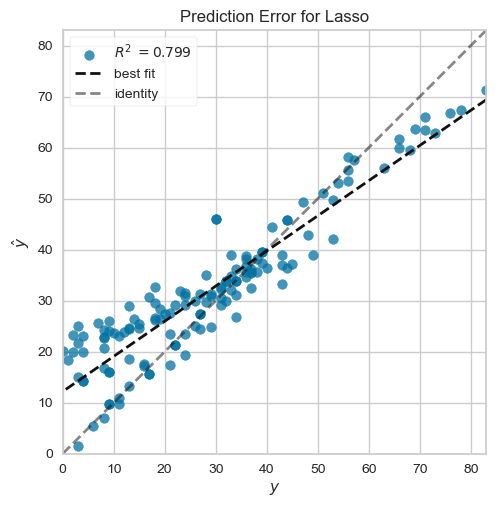

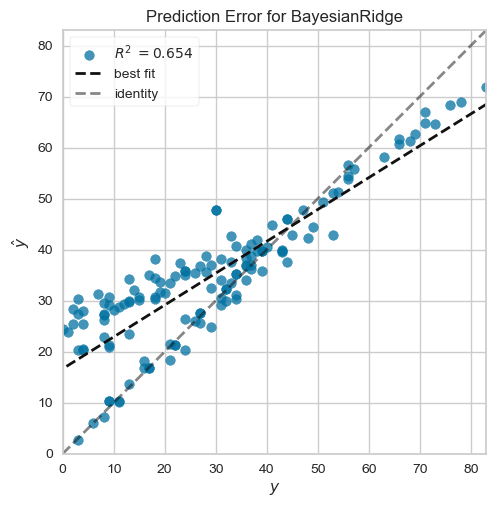

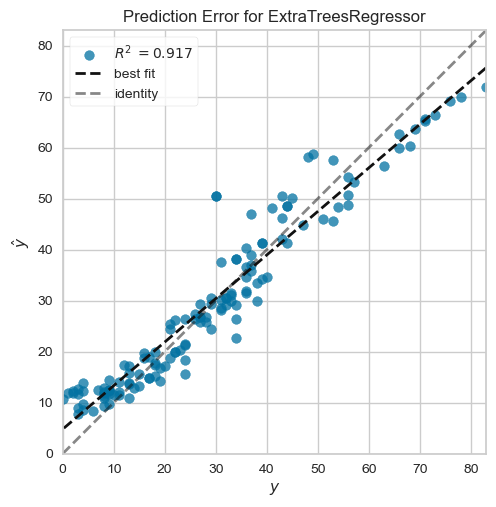

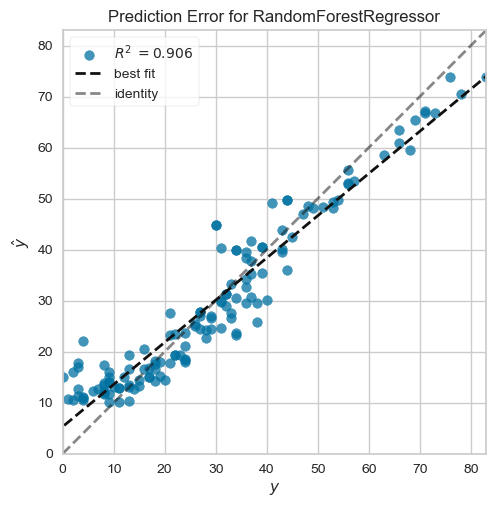

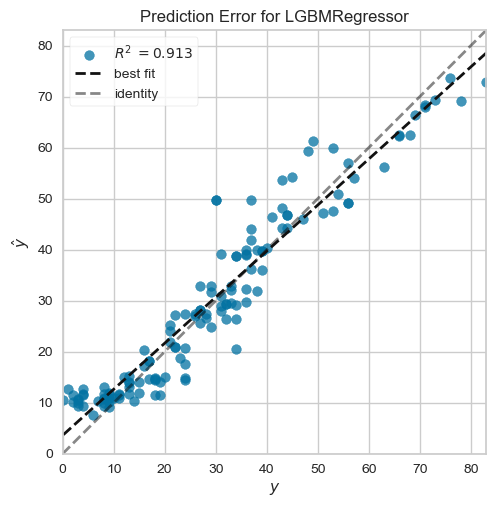

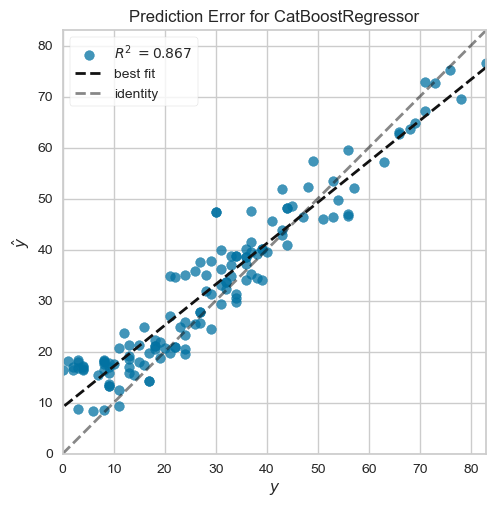

In [10]:
#--予測誤差プロット
plot_model(tuned_lasso, plot='error')
plot_model(tuned_br, plot='error')
plot_model(tuned_etr, plot='error')
plot_model(tuned_rfr, plot='error')
plot_model(tuned_lgbm, plot='error')
plot_model(tuned_cat, plot='error')

In [11]:
#--最終モデルの確定
final_lasso = finalize_model(tuned_lasso)
final_br = finalize_model(tuned_br)
final_etr = finalize_model(tuned_etr)
final_rfr = finalize_model(tuned_rfr)
final_lgbm = finalize_model(tuned_lgbm)
final_cat = finalize_model(tuned_cat)

In [8]:
#--テストデータで予測・評価（収穫日まで30日以内）
print("Lasso回帰")
pred_lasso = predict_model(final_lasso, data=TEST.query("Target_Days <= 30"))
print("Bayesian Ridge")
pred_br = predict_model(final_br, data=TEST.query("Target_Days <= 30"))
print("Extra Tree Regressor")
pred_etr = predict_model(final_etr, data=TEST.query("Target_Days <= 30"))
print("Random Forest")
pred_rfr = predict_model(final_rfr, data=TEST.query("Target_Days <= 30"))
print("LightGBM")
pred_lgbm = predict_model(final_lgbm, data=TEST.query("Target_Days <= 30"))
print("CatBoost")
pred_cat = predict_model(final_cat, data=TEST.query("Target_Days <= 30"))

Lasso回帰


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Regression,4.6899,31.1327,5.5797,0.6048,0.6239,0.6764


Bayesian Ridge


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Bayesian Ridge,4.3580,25.7081,5.0703,0.6736,0.5629,0.6479


Extra Tree Regressor


...

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,4.7095,36.1940,6.0161,0.5405,0.6420,0.5590


LightGBM


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,3.9246,25.8095,5.0803,0.6724,0.5853,0.4771


[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
CatBoost


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,CatBoost Regressor,4.3391,30.1702,5.4927,0.6170,0.6111,0.4677


In [9]:
#--テストデータで予測・評価
print("Lasso回帰")
pred_lasso = predict_model(final_lasso, data=TEST)
print("Bayesian Ridge")
pred_br = predict_model(final_br, data=TEST)
print("Extra Tree Regressor")
pred_etr = predict_model(final_etr, data=TEST)
print("Random Forest")
pred_rfr = predict_model(final_rfr, data=TEST)
print("LightGBM")
pred_lgbm = predict_model(final_lgbm, data=TEST)
print("CatBoost")
pred_cat = predict_model(final_cat, data=TEST)

Lasso回帰


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Regression,3.9293,23.0559,4.8017,0.9524,0.4092,0.3166


Bayesian Ridge


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Bayesian Ridge,4.0688,22.8960,4.7850,0.9528,0.3713,0.3107


Extra Tree Regressor


...

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,4.3661,31.0273,5.5702,0.9360,0.4238,0.2778


LightGBM


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,3.8063,24.4104,4.9407,0.9496,0.3864,0.2385


[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
CatBoost


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,CatBoost Regressor,3.6104,21.6897,4.6572,0.9553,0.4005,0.2261


In [14]:
#--Lasso回帰の回帰係数をチェック
reg = setup(
    data = TRAIN,
    target = target_col,
    ignore_features = ignore_cols,
    categorical_features = categorical_cols,
    verbose=False,
    session_id = 42,
)

coef = final_lasso.coef_
intercept = final_lasso.intercept_
feature_names = get_config('X_train_transformed').columns

# DataFrameを作成
lasso_coef = pd.DataFrame({
    'Feature': np.append(feature_names, 'Intercept'),
    'Coefficient': np.append(coef, intercept)
})
display(lasso_coef.query("Coefficient != 0"))

,Feature,Coefficient
4,TMP_max,-0.081590
6,GSR,0.005788
9,TmulGSR,0.008006
18,TmulGSR_05,0.000351
27,TmulGSR_10,0.005233
54,TmulGSR_25,-0.002031
58,TMP_max_30,-0.025418
59,APCPRA_30,-0.001306
63,TmulGSR_30,-0.004482
74,Intercept,82.469516


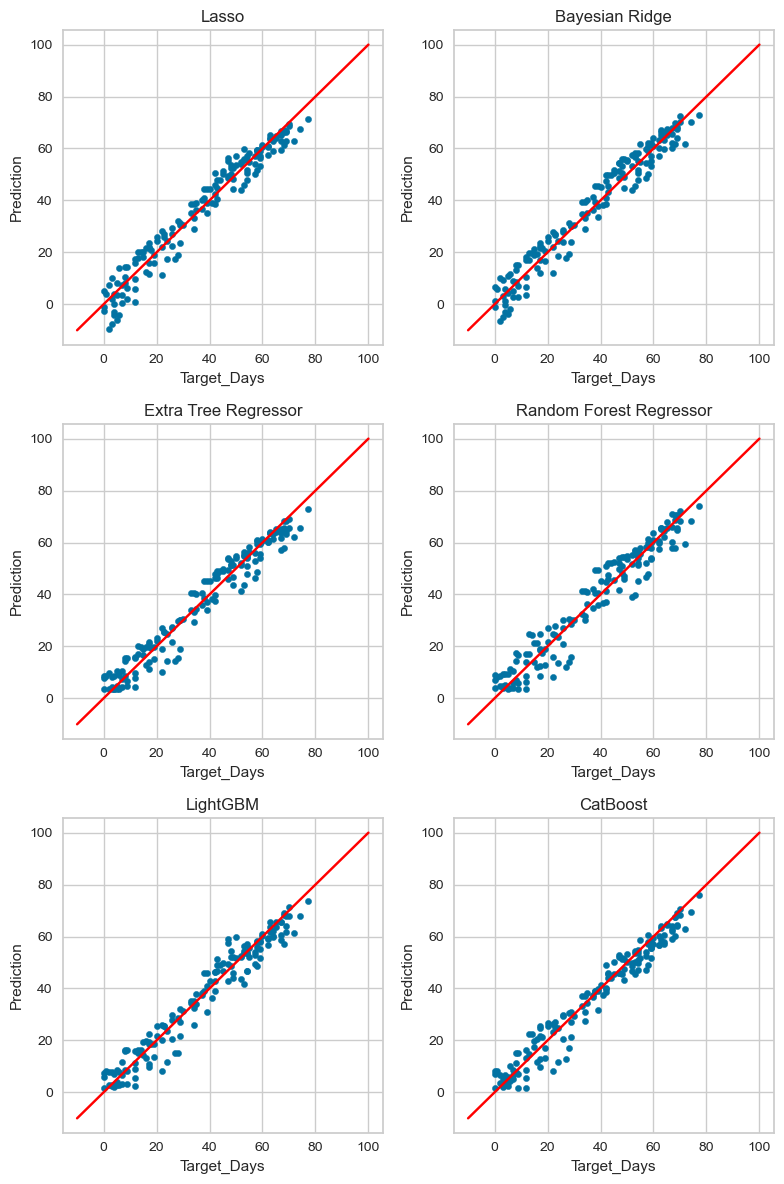

In [10]:
#--予測結果の散布図表示
result = [pred_lasso, pred_br, pred_etr, pred_rfr, pred_lgbm, pred_cat]
model_names = ['Lasso', 'Bayesian Ridge', 'Extra Tree Regressor', 'Random Forest Regressor', 'LightGBM', 'CatBoost']

fig = plt.figure(figsize=(8,12))
for model, result in zip(model_names, result):
    ax = fig.add_subplot(3, 2, model_names.index(model)+1)
    result.plot.scatter(x='Target_Days', y='prediction_label', ax=ax)
    ax.plot([-10,100], [-10,100], color='red')
    ax.set_ylabel('Prediction')
    ax.set_title(model)
plt.tight_layout()
plt.show()

,MAE,RMSE,R2,MAPE
0,6.749682,8.472733,0.851894,8.548234e+14


,MAE,RMSE,R2,MAPE
0,7.975758,9.865366,-0.235515,2.033443e+15


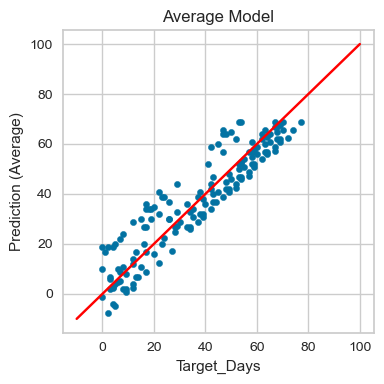

In [6]:
### 過去平均値モデル (ベンチマーク) ###
#--過去の平均値で予測
df_ave_model = pd.DataFrame({
    "MAE":[((TEST['remain_days'] - TEST['Target_Days']).abs()).mean()],
    "RMSE":[np.sqrt(((TEST['remain_days'] - TEST['Target_Days'])**2).mean())],
    "R2":[r2_score(TEST['Target_Days'], TEST['remain_days'])],
    "MAPE": [mean_absolute_percentage_error(TEST['Target_Days'], TEST['remain_days'])]
})
display(df_ave_model)

#--収穫日30日以内に絞った場合
TEST30 = TEST.query("Target_Days <= 30")
df_ave_model30 = pd.DataFrame({
    "MAE":[((TEST30['remain_days'] - TEST30['Target_Days']).abs()).mean()],
    "RMSE":[np.sqrt(((TEST30['remain_days'] - TEST30['Target_Days'])**2).mean())],
    "R2":[r2_score(TEST30['Target_Days'], TEST30['remain_days'])],
    "MAPE": [mean_absolute_percentage_error(TEST30['Target_Days'], TEST30['remain_days'])]
})
display(df_ave_model30)

#--散布図で可視化
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(1, 1, 1)
TEST.plot.scatter(x='Target_Days', y='remain_days', ax=ax)
ax.plot([-10,100], [-10,100], color='red')
ax.set_ylabel('Prediction (Average)')
ax.set_title('Average Model')
plt.tight_layout()
plt.show()

In [7]:
#--MAPEのみTarget_Days=0を除外して計算
df = TEST.query("Target_Days != 0")
print(((df['Target_Days'] - df['remain_days']).abs()/df['Target_Days']).mean())
df = TEST30.query("Target_Days != 0")
print(((df['Target_Days'] - df['remain_days']).abs()/df['Target_Days']).mean())

0.5224948324260313
1.1081207209450046


In [17]:
#--学習済みモデルの保存
save_dir = f"model/{test_year}_ex"
os.makedirs(save_dir, exist_ok=True)

save_model(final_lasso, f"{save_dir}/jpagri_lasso_model")
save_model(final_br, f"{save_dir}/jpagri_br_model")
save_model(final_etr, f"{save_dir}/jpagri_etr_model")
save_model(final_rfr, f"{save_dir}/jpagri_rfr_model")
save_model(final_lgbm, f"{save_dir}/jpagri_lgbm_model")
save_model(final_cat, f"{save_dir}/jpagri_cat_model")

Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['経過日', 'NDVI値', 'remain_NDVI',
                                              'TMP_mea', 'TMP_max', 'APCPRA',
                                              'GSR', 'TMP_GDD2', 'TMP_GDD5',
                                              'TmulGSR', 'RA_days', 'RH_ave',
                                              'TMP_mea_05', 'TMP_max_05',
                                              'APCPRA_05', 'GSR_05',
                                              'TMP_GDD2_05', 'TMP_GDD5_05',
                                              'TmulGSR_05', 'RA_days_05',
                                              'RH_ave_05', 'TMP_mea_10',
                                              'TMP_max_10', 'AP...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('onehot_encoding',
                  TransformerWrapper(include=['pl

In [7]:
#--学習済みモデルの読み込み
save_dir = f"model/{test_year}_ex"
final_lasso = load_model(f"{save_dir}/jpagri_lasso_model")
final_br = load_model(f"{save_dir}/jpagri_br_model")
final_etr = load_model(f"{save_dir}/jpagri_etr_model")
final_rfr = load_model(f"{save_dir}/jpagri_rfr_model")
final_lgbm = load_model(f"{save_dir}/jpagri_lgbm_model")
final_cat = load_model(f"{save_dir}/jpagri_cat_model")

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


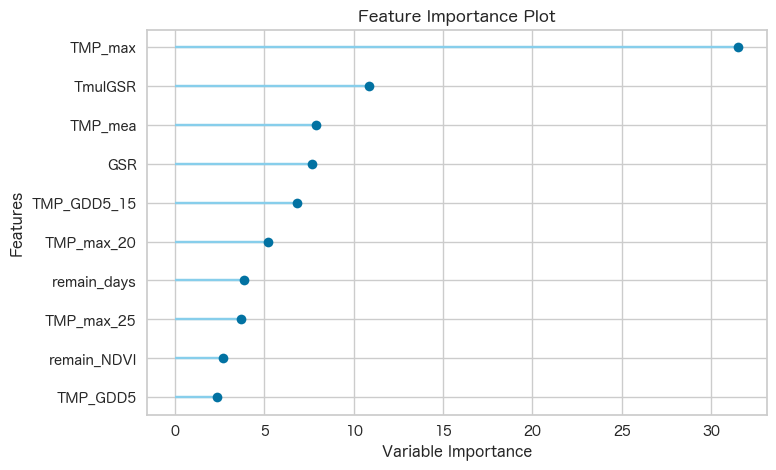

In [9]:
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Hiragino Maru Gothic Pro', 'Yu Gothic', 'Meirio']
reg = setup(
    data = TRAIN,
    target = target_col,
    ignore_features = ignore_cols,
    categorical_features = categorical_cols,
    verbose=False,
    session_id = 42,
)
plot_model(final_cat, plot='feature')

# END

In [18]:
# groups = []
# MAEs = []

# fig = plt.figure(figsize=(6,6))
# for i, (g, df) in enumerate(pred_etr.groupby('栽培グループ名')):
#     ax = fig.add_subplot(2,2,i+1)
#     df['error'] = df['prediction_label'] - df['Target_Days']
#     groups.append(g)
#     MAEs.append(df['error'].abs().mean())
#     df['error'].hist(ax=ax)
#     ax.set_title(g)
# plt.tight_layout()
# plt.show()

# pd.DataFrame({'group':groups, "MAE":MAEs})